In [1]:
import os
os.chdir('../../../../..')

In [47]:
import polars as pl
import numpy as np

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from kmedoids import KMedoids
from hdbscan import HDBSCAN

from src.helper_functions import create_chemiscope_viewer, average_numeric_by_cluster
from src.datasets import QM9Dataset
from src.non_euclidean import Riemann, Grassmann, Wasserstein

In [3]:
qm9 = QM9Dataset(limit=5000, descriptors=["soap"], sampling_strategy="stratified", stratify_by=["num_atoms", "gap"])
df = qm9.load()
soap_list = np.array(df["soap_embedding"].to_list())

2026-04-24 14:32:13.277 | INFO     | src.datasets:load:795 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-24 14:32:13.449 | INFO     | src.datasets:_sample_qm9_df:995 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-04-24 14:32:13.450 | INFO     | src.datasets:_add_requested_descriptors:187 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-04-24 14:32:13.722 | INFO     | src.features:compute_soap:193 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-04-24 14:32:48.496 | SUCCESS  | src.datasets:add_soap:1147 - Added SOAP embeddings.
2026-04-24 14:32:48.497 | INFO     | src.datasets:_add_requested_descriptors:212 - Added descriptor column(s): ['soap_embedding']
2026-04-24 14:32:48.537 | INFO     | src.datasets:_drop_rows_with_null_required_descriptors:888 - Dropped QM9 rows with null/empty descriptor vectors: dropped=14, remaining=5486, descriptor_cols=['soap_embedding'].
2026-04-24 

In [4]:
df[0]

mol_id,formula,smiles,canonical_smiles,scaffold_smiles,generic_scaffold,root_scaffold,brics_fragments,scaffold_tree_nodes,selfies,functional_groups,structure_class,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,is_injected,outlier_category,soap_embedding
str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,list[f64]
"""qm9_34""","""C3H6O""","""[H]C(=O)C([H])([H])C([H])([H])…","""[H]C(=O)C([H])([H])C([H])([H])…","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C(=O)C([H])([H])C([H])([H])…","""""","""[H][C][=Branch1][C][=O][C][Bra…","""""","""Acyclic""",58,0,17,0.977264,12.898953,4,0,0,0,1,10,1.8,2,0.0,0.333333,0.666667,0,1,3,0,1,2,4,20,1.213143,0,0,0,0,0,0,0,0,0,0,2.6741,35.830002,-6.802846,-0.557833,6.245013,333.327606,2.290518,-5253.84375,-5253.705566,-5253.679688,-5254.594727,15.954,-39.964523,-40.211521,-40.442844,-37.381725,26.145639,4.2893,4.12773,0,null,"[0.116376, 0.323321, … 0.0]"


In [5]:
soap_matrix = qm9.get_descriptor_matrices("soap")

2026-04-24 14:32:49.268 | INFO     | src.features:compute_soap:193 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...


In [10]:
riemann = Riemann()
dist_matrix = riemann.distance_matrix(feature_matrices=soap_matrix, n_pca=30)

2026-04-24 14:40:27.190 | INFO     | src.non_euclidean:distance_matrix:560 - Computing Riemann distance matrix | Features: invariant | Metric: log-euclidean
2026-04-24 14:40:27.191 | INFO     | src.non_euclidean:_get_spd_matrices:512 - Applying PCA to reduce feature dimension to 30...
Computing Distances: 100%|██████████| 5000/5000 [00:31<00:00, 161.26it/s]


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_86661/2043131933.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix, method='complete')


{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [10.0, 10.0, 30.0, 30.0],
  [45.0, 45.0, 55.0, 55.0],
  [65.0, 65.0, 75.0, 75.0],
  [50.0, 50.0, 70.0, 70.0],
  [20.0, 20.0, 60.0, 60.0],
  [85.0, 85.0, 95.0, 95.0],
  [105.0, 105.0, 115.0, 115.0],
  [90.0, 90.0, 110.0, 110.0],
  [125.0, 125.0, 135.0, 135.0],
  [145.0, 145.0, 155.0, 155.0],
  [130.0, 130.0, 150.0, 150.0],
  [100.0, 100.0, 140.0, 140.0],
  [40.0, 40.0, 120.0, 120.0],
  [165.0, 165.0, 175.0, 175.0],
  [185.0, 185.0, 195.0, 195.0],
  [170.0, 170.0, 190.0, 190.0],
  [205.0, 205.0, 215.0, 215.0],
  [225.0, 225.0, 235.0, 235.0],
  [210.0, 210.0, 230.0, 230.0],
  [180.0, 180.0, 220.0, 220.0],
  [245.0, 245.0, 255.0, 255.0],
  [265.0, 265.0, 275.0, 275.0],
  [250.0, 250.0, 270.0, 270.0],
  [285.0, 285.0, 295.0, 295.0],
  [305.0, 305.0, 315.0, 315.0],
  [290.0, 290.0, 310.0, 310.0],
  [260.0, 260.0, 300.0, 300.0],
  [200.0, 200.0, 280.0, 280.0],
  [80.0, 80.0, 240.0, 240.0],
  [325.0, 325.0, 335.0, 335.0],
  [345

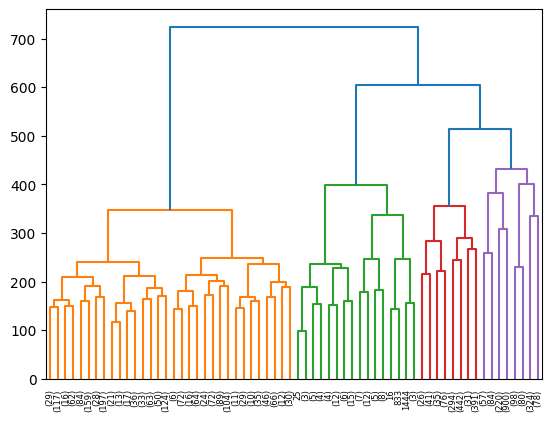

In [30]:
Z = linkage(dist_matrix, method='complete')

dendrogram(
    Z,
    truncate_mode='level',
    p=5, 
)

In [32]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1, 2, 3]), array([2544, 2060,  126,  270]))


In [56]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'MDS')

Running MDS dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_MDS_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_MDS_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [35]:
average_numeric_by_cluster(df, "labels_hier")

shape: (4, 72)
┌─────────────┬───────┬─────────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,is_injected,hier_labels,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2544,2.053882,123.247248,-0.285377,43.146226,0.784368,12.909602,8.803852,1.643868,0.170597,0.001965,2.816431,18.20794,2.06174,2.264544,0.05846,0.254875,0.686665,1.313679,2.077437,6.715016,0.358097,1.428066,4.201258,6.352987,37.670204,1.260054,0.002358,0.264151,0.039308,0.251179,0.252358,0.004324,0.03066,0.108491,0.398585,0.0,3.000977,74.665629,-6.367158,0.231775,6.598967,1174.983751,3.946458,-11258.712974,-11258.483019,-11258.457335,-11259.621901,31.393864,-74.533192,-74.983807,-75.411957,-69.355868,3.363025,1.400763,1.107564,0.0,1.0,73.152516,16.666667,10.180818,37.670204,934,"""Acyclic""",10.180818,238,"""C1CCCC1""",13.561321,1,null,0.0
1,2060,2.08124,123.029126,0.329612,29.51068,0.994998,12.757803,8.775728,1.705825,0.015534,0.002913,1.951456,18.921359,2.063702,2.5,0.069847,0.126251,0.803902,0.578641,1.946117,6.347573,0.478155,0.837864,5.508252,6.320388,39.593204,1.265119,0.000971,0.575243,0.001942,0.001456,0.000971,0.0,0.06068,0.183495,0.824272,0.0,2.384958,75.684282,-6.708513,0.550723,7.259302,1201.586195,4.322014,-11166.758686,-11166.52092,-11166.495223,-11167.674367,32.680819,-79.427813,-79.919155,-80.379695,-73.907875,3.194125,1.39281,1.137456,0.0,1.0,86.941748,1.553398,11.504854,39.593204,556,"""Acyclic""",11.504854,217,"""Acyclic""",11.504854,1,null,0.0
2,126,1.728713,112.452381,-0.02381,51.198413,0.651253,12.91206,8.198413,1.111111,0.761905,0.071429,3.396825,12.738095,2.011507,0.920635,0.166251,0.639853,0.193896,0.706349,2.928571,4.603175,0.912698,2.904762,0.984127,6.055556,22.238095,1.26662,0.0,0.007937,0.111111,0.18254,0.087302,0.007937,0.02381,0.039683,0.214286,0.007937,3.485166,66.246825,-6.777795,-1.125925,5.651913,1030.539195,2.50067,-10861.021213,-10860.82983,-10860.804102,-10861.888881,25.277444,-57.957124,-58.256043,-58.557278,-54.226182,5.401543,1.643413,1.248016,0.0,1.0,18.253968,71.428571,10.31746,22.238095,71,"""c1cocn1""",12.698413,22,"""C1CCCC1""",37.301587,1,null,0.0
3,270,2.157223,117.796296,1.625926,7.218519,0.936092,12.662794,8.733333,1.833333,0.003704,0.011111,0.355556,20.814815,2.065756,1.807407,0.134237,0.098618,0.767144,0.014815,0.333333,7.340741,1.048148,0.822222,6.507407,6.455556,45.303704,1.262226,0.0,0.003704,0.0,0.0,0.0,0.0,0.0,0.018519,0.007407,0.0,1.406953,86.20163,-6.740653,0.960774,7.701336,1277.996954,4.940632,-9462.61937,-9462.380257,-9462.354539,-9463.533171,33.702544,-87.858149,-88.419292,-88.927275,-81.823352,3.762358,1.329353,1.112791,0.0,1.0,86.296296,0.37037,13.333333,45.303704,102,"""Acyclic""",13.333333,70,"""Acyclic""",13.333333,1,null,0.0


# KMedoids

In [41]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)
print(np.unique(labels_km, return_counts=True))

(array([0, 1, 2], dtype=uint64), array([1755, 2311,  934]))


In [43]:
#average_numeric_by_cluster(df, labels_km)

In [55]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'MDS')

Running MDS dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_MDS_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_MDS_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

# HDBSCAN

In [53]:
hdbscan = HDBSCAN(min_cluster_size=10, min_samples=100, metric='precomputed')
labels_hdbscan = hdbscan.fit_predict(dist_matrix)
df = df.with_columns(labels_hdbscan=labels_hdbscan)
print(np.unique(labels_hdbscan, return_counts=True))

(array([-1,  0,  1]), array([3638, 1347,   15]))


In [51]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'ISOMAP')

Running ISOMAP dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_ISOMAP_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_ISOMAP_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - ISOMAP Clustering'}, settings={'map': {'x': {'property': 'ISOMAP_1'}, '…